In [1]:
from src.l_curve import create_L_curve
import matplotlib.pyplot as plt
import pandas as pd
import os
import firedrake

2024-11-02 12:14:08.028603: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-02 12:14:12.492616: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-02 12:14:15.450020: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1730549658.515115    1092 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1730549659.058345    1092 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-02 12:14:24.937532: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [2]:
def plot_lcurve(l_curve,loglog=False):
    # Plot
    plt.figure(figsize=(10, 6))

    # Plot scatter points
    if loglog:
        plt.loglog(l_curve['J1'], l_curve['J2'], marker='o', linestyle='', label='Regularization constant')
    else:
        plt.plot(l_curve['J1'], l_curve['J2'], marker='o', linestyle='', label='Regularization constant')

    # Plot line connecting the points
    if loglog:
        plt.loglog(l_curve['J1'], l_curve['J2'], marker='', linestyle='-')
    else:
        plt.plot(l_curve['J1'], l_curve['J2'], marker='', linestyle='-')

    # Annotate points with regularization values
    for i, txt in enumerate(l_curve['Regularization Constant']):
        plt.annotate(txt, (l_curve['J1'][i], l_curve['J2'][i]))

    plt.xlabel('E')
    plt.ylabel('R')
    plt.title('Log-Log Plot of E vs R with Regularization Constants')
    plt.legend()
    plt.grid(True)
    plt.show()

In [3]:
variable = 'C'

In [4]:
reg_const_list = [0.01, 0.05, 0.1, 0.5, 1, 10]

#### Thwaites L-curve

In [4]:
l_curve = create_L_curve(None, variable,reg_const_list = reg_const_list, outline='data/geojson/thwaites.geojson', mesh='thwaites', invert_iter = 170, workers = 4,  lcar=9e3, nosigma_lossfcn = 'nosigma', drichlet_ids = [1,2,5,6], regularization_grad_fcn = True, constant_val=0.01)


 function started for C 1
 function started for C 0.01
 function started for C 0.1

 function started for C 10

Reading local outline
Reading local outlineReading local outlineReading local outline



Creating meshCreating mesh
Creating mesh
Creating mesh

Reading meshReading meshReading mesh


Reading mesh
Reading bedmachine dataReading bedmachine data

Reading bedmachine data
Reading bedmachine data
Initializing function spaces
Initializing function spaces
Initializing function spaces
Initializing 3d function spaces
Initializing function spaces
Initializing 3d function spaces
Initializing fields
Initializing fields
Initializing 3d function spaces
Initializing fieldsInitializing 3d function spaces

Initializing fields
Defining friction law
Setting ramp power to :  1
Initializing heat transport
Reading velocity from measures database
Defining friction law
Setting ramp power to :  1
Initializing heat transport
Reading velocity from measures database
Defining friction law
Setting ramp p

In [13]:
# data = {
#     'reg': [0.01, 0.1, 1, 10],
#     'J1': [568.5430921059252, 200.15193884090579, 125.05111469154097, 131.02607789480362],
#     'J2': [0.029821845834902418, 0.5584096178962419, 10.077985527278557, 16.01170699159037]
# }

# l_curve = pd.DataFrame(data)
l_curve_thwaites = l_curve.sort_values('Regularization Constant')
l_curve_thwaites_2 = l_curve_thwaites.copy()
l_curve_thwaites_2['J2'] = l_curve_thwaites_2['J2']/(l_curve_thwaites_2['Regularization Constant']**2)

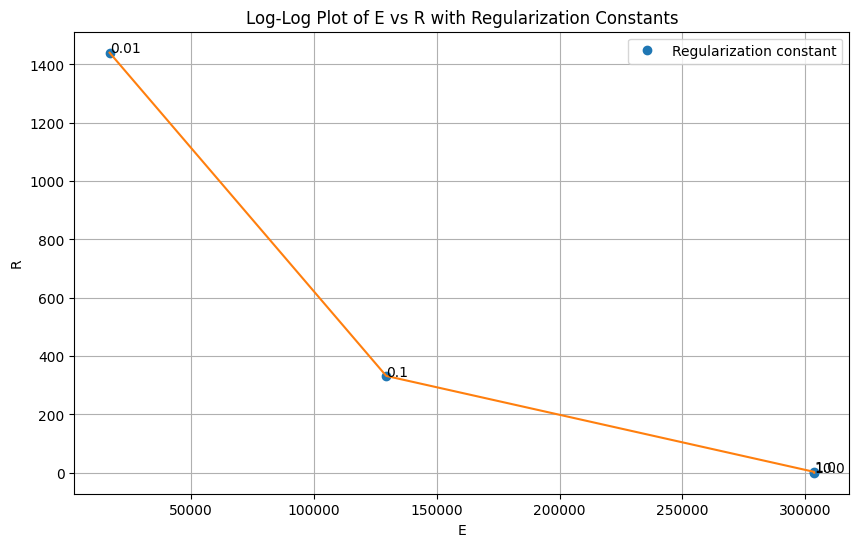

In [14]:
plot_lcurve(l_curve_thwaites_2, loglog=False)

#### Dotson L-curve

In [ ]:
l_curve = create_L_curve(None, variable,reg_const_list = reg_const_list, outline='data/geojson/dotson-crosson.geojson', mesh='dotson', invert_iter = 300, workers = 4,  lcar=9e3, nosigma_lossfcn = 'nosigma', drichlet_ids = [1,2,5,6,7,8,9,10,11], regularization_grad_fcn = True, constant_val=0.01)


 function started for C 0.05
 function started for C 0.01
 function started for C 0.5
 function started for C 0.1



Reading local outlineReading local outlineReading local outlineReading local outline



Creating meshCreating meshCreating meshCreating mesh



Reading mesh
Reading mesh
Reading meshReading mesh

Reading bedmachine data
Reading bedmachine data
Reading bedmachine data
Reading bedmachine data
Initializing function spaces
Initializing function spaces
Initializing function spaces
Initializing 3d function spaces
Initializing 3d function spaces
Initializing fields
Initializing 3d function spaces
Initializing fields
Initializing fields
Initializing function spaces
Defining friction lawDefining friction law

Setting ramp power to :  Setting ramp power to : 1 
1
Initializing heat transportInitializing heat transport

Reading velocity from measures databaseReading velocity from measures database

Defining friction law
Setting ramp power to :  1
Initializing heat transport
Reading

In [18]:

# data = {
#     'Regularization Constant': [0.01, 0.1, 1, 10, 100],
#     'J1': [2267.6773361353717, 1048.1822885449558, 920.1322010148269, 3572.6007040486306, 3571.8336010333956],
#     'J2': [0.08733750798441621, 1.5586142772894822,27.761524638326396, 23.613921786056103, 23.61655309695598]
# }

#l_curve = pd.DataFrame(data)
l_curve_dotson = l_curve.sort_values('Regularization Constant')
l_curve_dotson_2 = l_curve_dotson.copy()
l_curve_dotson_2['J2'] = l_curve_dotson_2['J2']/(l_curve_dotson_2['Regularization Constant']**2)


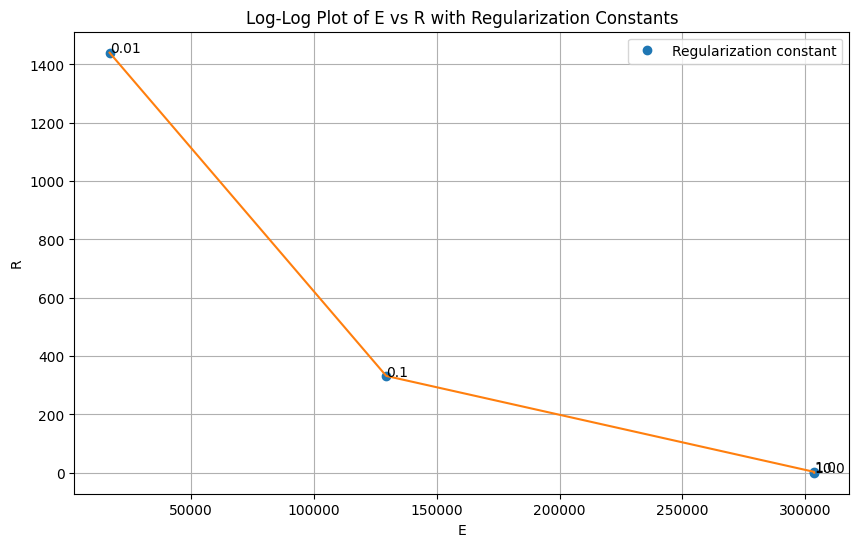

In [19]:
plot_lcurve(l_curve_dotson_2, loglog=False)

#### Pine Island L Curve

In [5]:
l_curve = create_L_curve(None, variable,reg_const_list = reg_const_list, outline= 'pine-island', mesh = 'pig', invert_iter = 300, workers = 4,  lcar=9e3, nosigma_lossfcn = 'nosigma', drichlet_ids = [2,3,4], regularization_grad_fcn = True, constant_val=0.01)


 function started for C 0.01
 function started for C 0.5

 function started for C 0.1
 function started for C 0.05Reading outline from icepack database

Reading outline from icepack database
Reading outline from icepack database


Reading outline from icepack database
Creating meshCreating meshCreating meshCreating mesh



Reading mesh
Reading meshReading meshReading mesh


Reading bedmachine dataReading bedmachine dataReading bedmachine dataReading bedmachine data



Initializing function spacesInitializing function spacesInitializing function spacesInitializing function spaces



Initializing 3d function spacesInitializing 3d function spaces

Initializing 3d function spaces
Initializing 3d function spaces
Initializing fields
Initializing fields
Initializing fields
Initializing fields
Defining friction lawDefining friction lawDefining friction lawDefining friction law



Setting ramp power to : Setting ramp power to : Setting ramp power to : Setting ramp power to :     1111



Initia

In [6]:
l_curve_pine_island = l_curve.sort_values('Regularization Constant')
l_curve_pine_island_2 = l_curve_pine_island.copy()
l_curve_pine_island_2['J2'] = l_curve_pine_island_2['J2']/(l_curve_pine_island_2['Regularization Constant']**2)

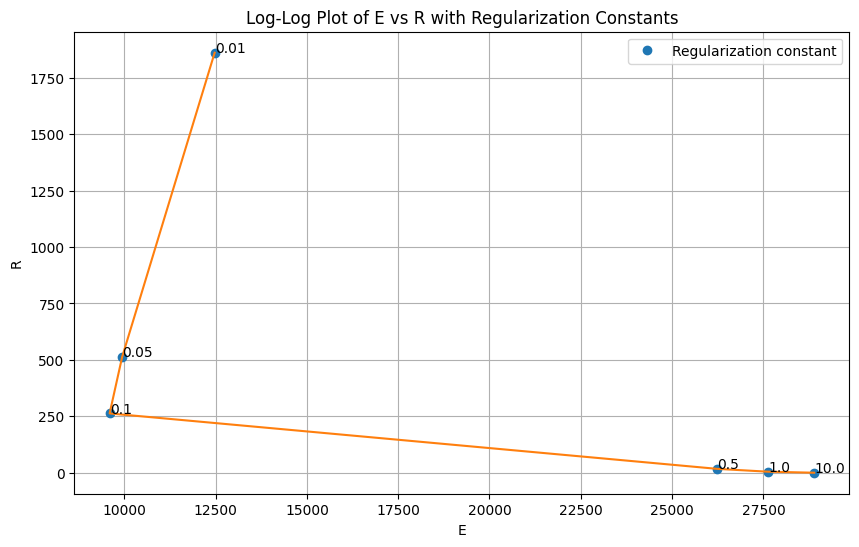

In [7]:
plot_lcurve(l_curve_pine_island_2, loglog=False)